# Support Vector Machine (SVM) para Detecção de Alzheimer

## Objetivo
Este notebook implementa um **classificador SVM (Support Vector Machine)** otimizado para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Sobre SVM
O SVM é um algoritmo que encontra o **hiperplano ótimo** que separa as classes com a maior margem possível. É especialmente eficaz em espaços de alta dimensão e quando o número de features é maior que o número de amostras.

### Características do SVM:
- **Kernel Trick**: Permite classificar dados não-linearmente separáveis
- **Vetores de Suporte**: Usa apenas os pontos mais importantes
- **Regularização**: Parâmetro C controla o trade-off entre margem e erros
- **Efetivo em alta dimensão**: Funciona bem com muitas features

### Tipos de Kernel:
- **Linear**: Para dados linearmente separáveis
- **RBF (Radial Basis Function)**: Kernel mais versátil
- **Polynomial**: Captura relações polinomiais
- **Sigmoid**: Similar a redes neurais

## Métricas Importantes para Diagnóstico Médico
- **Recall**: Capacidade de identificar corretamente os casos positivos
- **Precisão**: Proporção de diagnósticos positivos corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC

## 1. Importação das Bibliotecas

In [1]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

import os

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Dimensões: 2149 amostras x 35 features


In [3]:
# ==============================================================================
# EXPLORAÇÃO INICIAL
# ==============================================================================

print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

## 3. Pré-processamento dos Dados

In [4]:
# ==============================================================================
# PRÉ-PROCESSAMENTO
# ==============================================================================

colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Duplicatas: {df.duplicated().sum()}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

Valores nulos: 0
Duplicatas: 0


## 4. Análise da Variável Alvo

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)


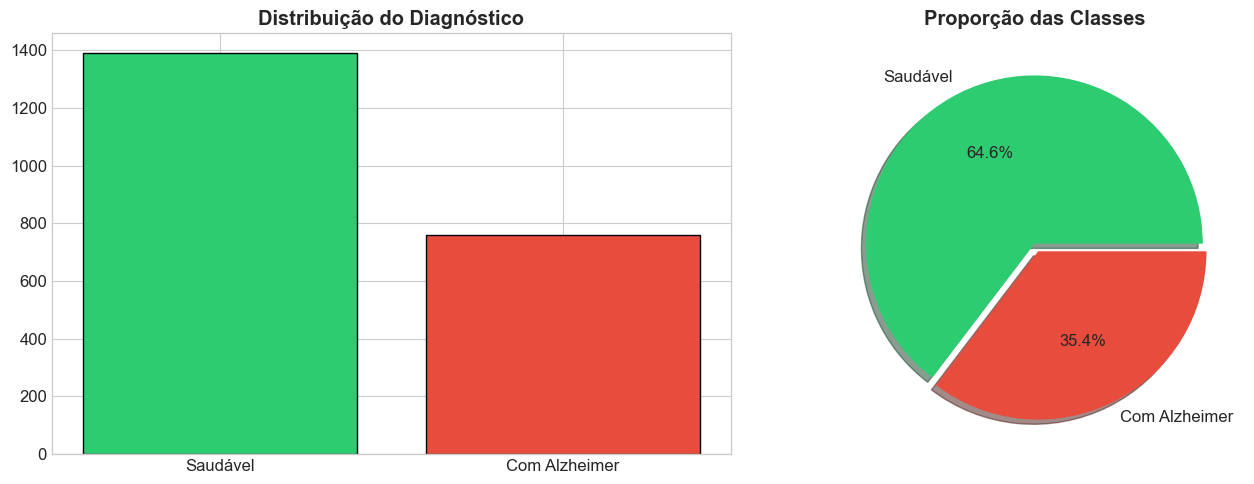

In [5]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO
# ==============================================================================

contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Saudável', 'Com Alzheimer'], 
            [contagem_classes[0], contagem_classes[1]], 
            color=colors, edgecolor='black')
axes[0].set_title('Distribuição do Diagnóstico', fontweight='bold')

axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('svm_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento e Preparação dos Dados

In [6]:
# ==============================================================================
# SEPARAÇÃO E BALANCEAMENTO
# ==============================================================================

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Após SMOTE: {len(y_balanced)} amostras")
print(f"  - Classe 0: {sum(y_balanced == 0)}")
print(f"  - Classe 1: {sum(y_balanced == 1)}")

Após SMOTE: 2778 amostras
  - Classe 0: 1389
  - Classe 1: 1389


In [7]:
# ==============================================================================
# DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# NORMALIZAÇÃO - ESSENCIAL PARA SVM!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalização aplicada (StandardScaler)")
print("  IMPORTANTE: SVM é MUITO sensível à escala dos dados!")

feature_names = X.columns.tolist()

Treino: 2083 amostras
Teste: 695 amostras

Normalização aplicada (StandardScaler)
  IMPORTANTE: SVM é MUITO sensível à escala dos dados!


## 6. Comparação de Kernels

COMPARAÇÃO DE KERNELS SVM

Treinando SVM com kernel linear...
  Acurácia: 83.02%
  F1-Score: 83.52%

Treinando SVM com kernel rbf...
  Acurácia: 85.90%
  F1-Score: 86.08%

Treinando SVM com kernel poly...
  Acurácia: 82.59%
  F1-Score: 83.89%

Treinando SVM com kernel sigmoid...
  Acurácia: 80.86%
  F1-Score: 81.60%


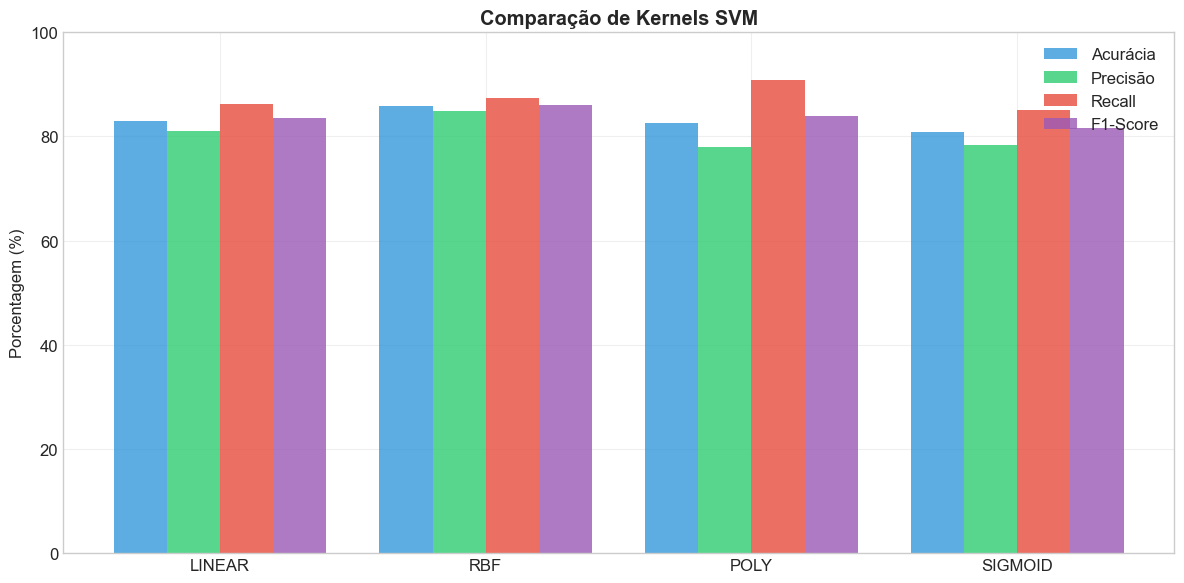


Melhor kernel (por F1-Score): RBF


In [8]:
# ==============================================================================
# COMPARAÇÃO DE DIFERENTES KERNELS
# ==============================================================================

print("=" * 60)
print("COMPARAÇÃO DE KERNELS SVM")
print("=" * 60)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
resultados_kernels = {}

for kernel in kernels:
    print(f"\nTreinando SVM com kernel {kernel}...")
    
    svm = SVC(kernel=kernel, random_state=RANDOM_STATE, probability=True)
    svm.fit(X_train_scaled, y_train)
    y_pred_k = svm.predict(X_test_scaled)
    
    resultados_kernels[kernel] = {
        'accuracy': accuracy_score(y_test, y_pred_k),
        'precision': precision_score(y_test, y_pred_k),
        'recall': recall_score(y_test, y_pred_k),
        'f1': f1_score(y_test, y_pred_k)
    }
    
    print(f"  Acurácia: {resultados_kernels[kernel]['accuracy']*100:.2f}%")
    print(f"  F1-Score: {resultados_kernels[kernel]['f1']*100:.2f}%")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(kernels))
width = 0.2

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
labels = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

for i, (metric, color, label) in enumerate(zip(metrics, colors_bar, labels)):
    valores = [resultados_kernels[k][metric]*100 for k in kernels]
    ax.bar(x + i*width, valores, width, label=label, color=color, alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação de Kernels SVM', fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels([k.upper() for k in kernels])
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_comparacao_kernels.png', dpi=150, bbox_inches='tight')
plt.show()

# Melhor kernel
best_kernel = max(resultados_kernels, key=lambda k: resultados_kernels[k]['f1'])
print(f"\nMelhor kernel (por F1-Score): {best_kernel.upper()}")

## 7. Modelo SVM Base (RBF)

In [9]:
# ==============================================================================
# MODELO BASE (RBF COM PARÂMETROS PADRÃO)
# ==============================================================================

print("=" * 60)
print("MODELO SVM BASE (RBF, C=1.0, gamma='scale')")
print("=" * 60)

svm_base = SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True)
svm_base.fit(X_train_scaled, y_train)

y_pred_base = svm_base.predict(X_test_scaled)
y_proba_base = svm_base.predict_proba(X_test_scaled)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"\nResultados do Modelo Base:")
print(f"  Acurácia:  {acc_base*100:.2f}%")
print(f"  Precisão:  {prec_base*100:.2f}%")
print(f"  Recall:    {rec_base*100:.2f}%")
print(f"  F1-Score:  {f1_base*100:.2f}%")
print(f"\n  Número de Vetores de Suporte: {sum(svm_base.n_support_)}")

MODELO SVM BASE (RBF, C=1.0, gamma='scale')

Resultados do Modelo Base:
  Acurácia:  85.90%
  Precisão:  84.87%
  Recall:    87.32%
  F1-Score:  86.08%

  Número de Vetores de Suporte: 1171


## 8. GridSearch para Otimização

Principais hiperparâmetros do SVM:
- **C**: Parâmetro de regularização (trade-off margem vs erros)
- **gamma**: Coeficiente do kernel RBF (controla a "influência" de cada ponto)
- **kernel**: Tipo de kernel a usar

In [10]:
# ==============================================================================
# GRIDSEARCH PARA OTIMIZAÇÃO
# ==============================================================================

print("=" * 60)
print("GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

print("\nGrade de hiperparâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(random_state=RANDOM_STATE, probability=True),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nExecutando GridSearch (pode demorar alguns minutos)...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n" + "=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_*100:.2f}%")

GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS

Grade de hiperparâmetros:
  C: [0.1, 1, 10, 100]
  gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1]
  kernel: ['rbf', 'linear', 'poly']

Executando GridSearch (pode demorar alguns minutos)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS:
  C: 1
  gamma: auto
  kernel: rbf

Melhor F1-Score (CV): 83.56%


## 9. Modelo Final Otimizado

In [11]:
# ==============================================================================
# MODELO FINAL OTIMIZADO
# ==============================================================================

print("=" * 60)
print("AVALIAÇÃO DO MODELO SVM OTIMIZADO")
print("=" * 60)

svm_otimizado = grid_search.best_estimator_

y_pred = svm_otimizado.predict(X_test_scaled)
y_proba = svm_otimizado.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMétricas no Conjunto de Teste:")
print(f"  Acurácia:  {accuracy*100:.2f}%")
print(f"  Precisão:  {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")
print(f"\n  Número de Vetores de Suporte: {sum(svm_otimizado.n_support_)}")

print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Alzheimer']))

AVALIAÇÃO DO MODELO SVM OTIMIZADO

Métricas no Conjunto de Teste:
  Acurácia:  85.90%
  Precisão:  84.87%
  Recall:    87.32%
  F1-Score:  86.08%

  Número de Vetores de Suporte: 1171

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

    Saudável       0.87      0.84      0.86       348
   Alzheimer       0.85      0.87      0.86       347

    accuracy                           0.86       695
   macro avg       0.86      0.86      0.86       695
weighted avg       0.86      0.86      0.86       695



## 10. Comparação: Base vs Otimizado

COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO

Métrica         Base                 Otimizado            Melhoria       
----------------------------------------------------------------------
Acurácia                    85.90%             85.90%        +0.00%
Precisão                    84.87%             84.87%        +0.00%
Recall                      87.32%             87.32%        +0.00%
F1-Score                    86.08%             86.08%        +0.00%


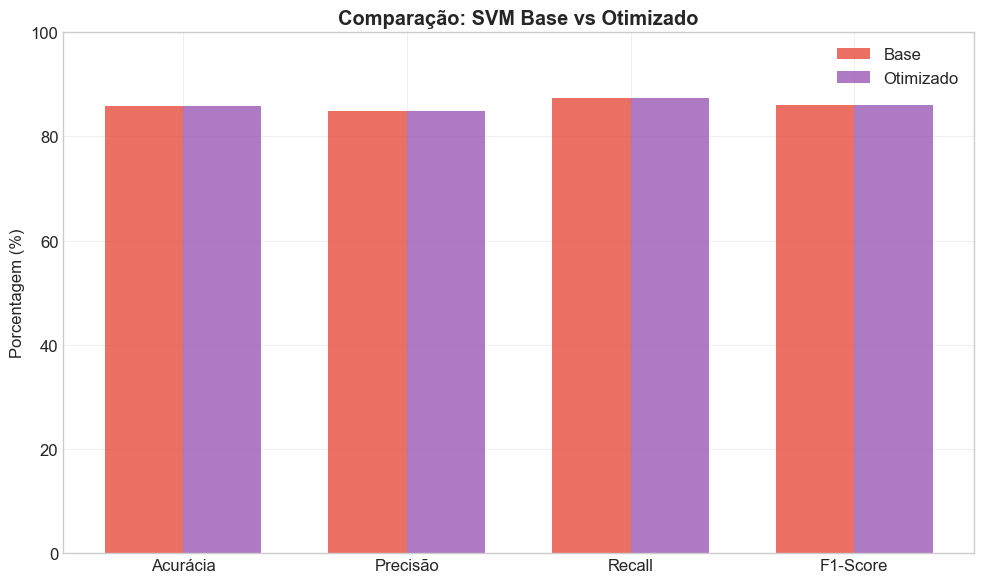

In [12]:
# ==============================================================================
# COMPARAÇÃO BASE vs OTIMIZADO
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO")
print("=" * 70)

print(f"\n{'Métrica':<15} {'Base':<20} {'Otimizado':<20} {'Melhoria':<15}")
print("-" * 70)
print(f"{'Acurácia':<15} {acc_base*100:>17.2f}% {accuracy*100:>17.2f}% {(accuracy-acc_base)*100:>+12.2f}%")
print(f"{'Precisão':<15} {prec_base*100:>17.2f}% {precision*100:>17.2f}% {(precision-prec_base)*100:>+12.2f}%")
print(f"{'Recall':<15} {rec_base*100:>17.2f}% {recall*100:>17.2f}% {(recall-rec_base)*100:>+12.2f}%")
print(f"{'F1-Score':<15} {f1_base*100:>17.2f}% {f1*100:>17.2f}% {(f1-f1_base)*100:>+12.2f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_base = [acc_base*100, prec_base*100, rec_base*100, f1_base*100]
valores_otim = [accuracy*100, precision*100, recall*100, f1*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, valores_base, width, label='Base', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valores_otim, width, label='Otimizado', color='#9b59b6', alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação: SVM Base vs Otimizado', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Matriz de Confusão e Curvas

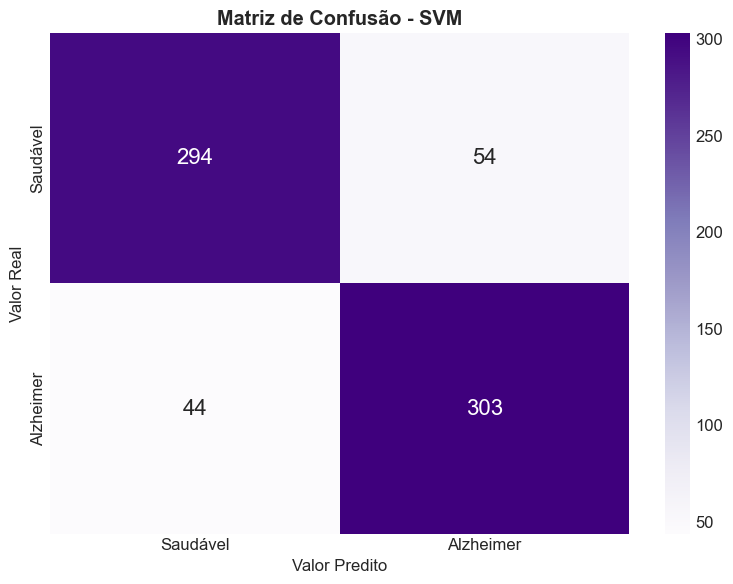

TN: 294, TP: 303, FP: 54, FN: 44


In [13]:
# ==============================================================================
# MATRIZ DE CONFUSÃO
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
plt.title('Matriz de Confusão - SVM', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('svm_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, TP: {tp}, FP: {fp}, FN: {fn}")

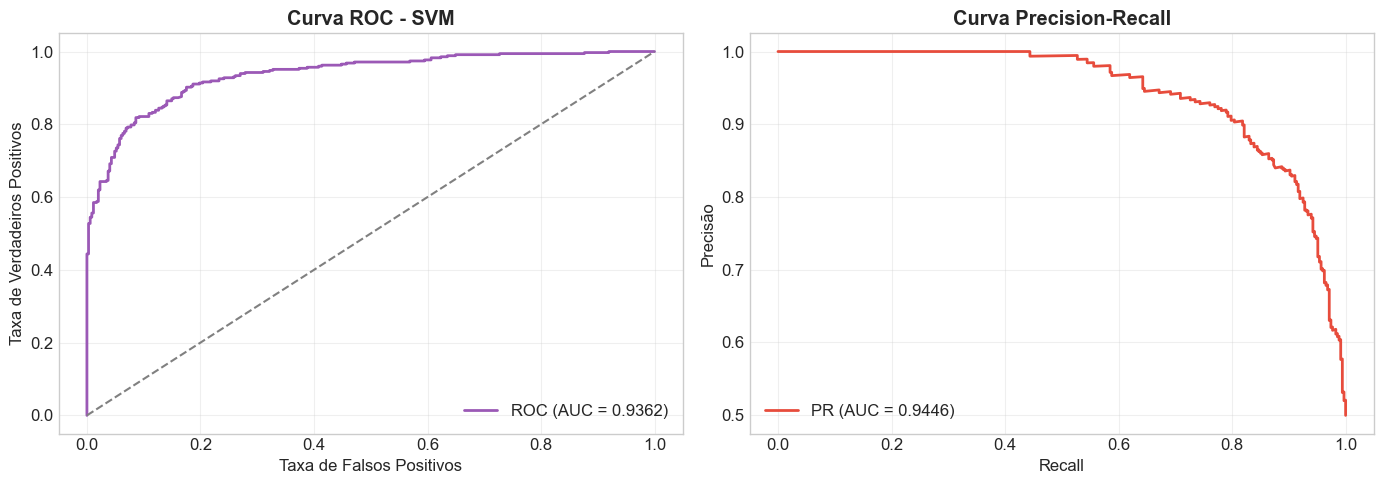

AUC-ROC: 0.9362
AUC-PR: 0.9446


In [14]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#9b59b6', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC - SVM', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

## 12. Análise dos Vetores de Suporte

ANÁLISE DOS VETORES DE SUPORTE

Vetores de Suporte por classe:
  - Classe 0 (Saudável): 606
  - Classe 1 (Alzheimer): 565
  - Total: 1171

Proporção de Vetores de Suporte:
  56.2% dos dados de treino são vetores de suporte


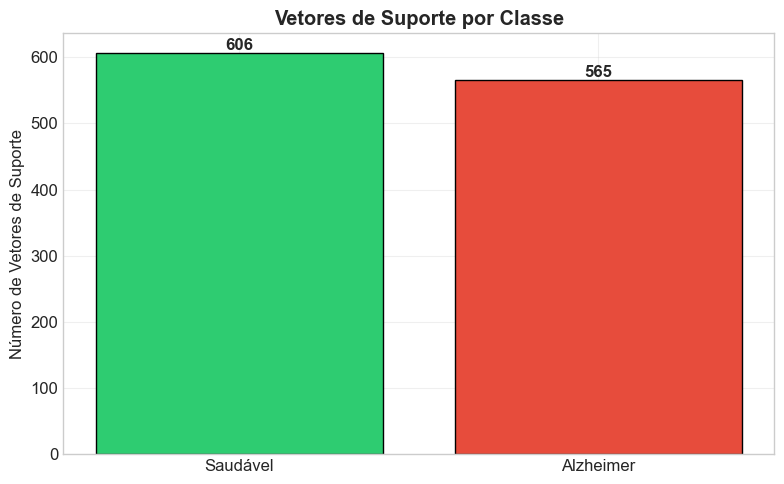

In [15]:
# ==============================================================================
# ANÁLISE DOS VETORES DE SUPORTE
# ==============================================================================

print("=" * 60)
print("ANÁLISE DOS VETORES DE SUPORTE")
print("=" * 60)

n_sv = svm_otimizado.n_support_
sv_indices = svm_otimizado.support_

print(f"\nVetores de Suporte por classe:")
print(f"  - Classe 0 (Saudável): {n_sv[0]}")
print(f"  - Classe 1 (Alzheimer): {n_sv[1]}")
print(f"  - Total: {sum(n_sv)}")

print(f"\nProporção de Vetores de Suporte:")
print(f"  {sum(n_sv)/len(y_train)*100:.1f}% dos dados de treino são vetores de suporte")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Saudável', 'Alzheimer'], n_sv, color=colors, edgecolor='black')
ax.set_ylabel('Número de Vetores de Suporte')
ax.set_title('Vetores de Suporte por Classe', fontweight='bold')

for bar, n in zip(bars, n_sv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(n), 
            ha='center', fontweight='bold')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_vetores_suporte.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Conclusão

In [16]:
# ==============================================================================
# RESUMO FINAL
# ==============================================================================

print("=" * 70)
print("RESUMO FINAL - SVM PARA DETECÇÃO DE ALZHEIMER")
print("=" * 70)

print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nDesempenho Final:")
print(f"  - Acurácia:  {accuracy*100:.2f}%")
print(f"  - Precisão:  {precision*100:.2f}%")
print(f"  - Recall:    {recall*100:.2f}%")
print(f"  - F1-Score:  {f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.4f}")

print(f"\nVetores de Suporte: {sum(n_sv)} ({sum(n_sv)/len(y_train)*100:.1f}% do treino)")

print("\n" + "=" * 70)
print("VANTAGENS DO SVM:")
print("=" * 70)
print("""
  1. EFETIVO EM ALTA DIMENSÃO: Funciona bem com muitas features
  2. KERNEL TRICK: Classifica dados não-linearmente separáveis
  3. MEMÓRIA EFICIENTE: Usa apenas vetores de suporte
  4. MARGEM MÁXIMA: Busca a melhor separação entre classes
  5. REGULARIZAÇÃO: Controle contra overfitting (parâmetro C)
""")

print("LIMITAÇÕES:")
print("""
  1. SENSÍVEL À ESCALA: Requer normalização obrigatória
  2. LENTO EM GRANDES DATASETS: O(n^2) a O(n^3) de complexidade
  3. ESCOLHA DE KERNEL: Requer experimentação
  4. PROBABILIDADES CALIBRADAS: Necessita Platt scaling
  5. NÃO DÁ IMPORTÂNCIA DE FEATURES: Difícil interpretar
""")

RESUMO FINAL - SVM PARA DETECÇÃO DE ALZHEIMER

Melhores Hiperparâmetros:
  - C: 1
  - gamma: auto
  - kernel: rbf

Desempenho Final:
  - Acurácia:  85.90%
  - Precisão:  84.87%
  - Recall:    87.32%
  - F1-Score:  86.08%
  - AUC-ROC:   0.9362

Vetores de Suporte: 1171 (56.2% do treino)

VANTAGENS DO SVM:

  1. EFETIVO EM ALTA DIMENSÃO: Funciona bem com muitas features
  2. KERNEL TRICK: Classifica dados não-linearmente separáveis
  3. MEMÓRIA EFICIENTE: Usa apenas vetores de suporte
  4. MARGEM MÁXIMA: Busca a melhor separação entre classes
  5. REGULARIZAÇÃO: Controle contra overfitting (parâmetro C)

LIMITAÇÕES:

  1. SENSÍVEL À ESCALA: Requer normalização obrigatória
  2. LENTO EM GRANDES DATASETS: O(n^2) a O(n^3) de complexidade
  3. ESCOLHA DE KERNEL: Requer experimentação
  4. PROBABILIDADES CALIBRADAS: Necessita Platt scaling
  5. NÃO DÁ IMPORTÂNCIA DE FEATURES: Difícil interpretar

